# 📊 Análisis de Factibilidad Financiera: Programa de Bienestar Corporativo

Este notebook modela el impacto financiero de implementar un curso para dejar de fumar en la organización. El objetivo es calcular el **Retorno de Inversión (ROI)** basándonos en la reducción de "costos ocultos" (pérdida de productividad y absentismo).

### Metodología
Utilizaremos un enfoque de **Análisis de Sensibilidad**, proyectando tres escenarios posibles para determinar la viabilidad del proyecto:
1. **Conservador:** 10% de éxito.
2. **Moderado:** 30% de éxito.
3. **Optimista:** 50% de éxito.

---

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.ticker as mtick # Para formatear ejes con signos de dinero/porcentaje

# Configuración estética de las gráficas para que se vean profesionales
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

## 1. Motor de Cálculo: Costos Ocultos

Primero, definimos la función para calcular cuánto dinero pierde la empresa actualmente debido al tabaquismo (Línea Base).

**Supuestos del Modelo:**
* **Pausas:** Se estiman 60 minutos perdidos al día por fumador.
* **Absentismo:** Se estiman 3 días extra de enfermedad al año por fumador.
* **Año Laboral:** 250 días.

La fórmula del costo por improductividad es:

$$Costo = NumFumadores \times MinutosPerdidos \times CostoMinuto \times DiasLaborales$$

---

In [2]:
def calcular_costo_actual(num_empleados, salario_mensual, pct_fumadores):
    """Calcula el costo oculto actual (Línea Base)"""
    # Constantes
    MINUTOS_PERDIDOS_DIA = 60
    DIAS_LABORALES_ANIO = 250
    DIAS_EXTRA_AUSENTISMO = 3
    
    # Tasas salariales
    salario_diario = salario_mensual / 30
    salario_minuto = salario_diario / 8 / 60
    
    num_fumadores = int(num_empleados * pct_fumadores)
    
    # Cálculo de Costos
    costo_pausas = num_fumadores * MINUTOS_PERDIDOS_DIA * salario_minuto * DIAS_LABORALES_ANIO
    costo_absentismo = num_fumadores * DIAS_EXTRA_AUSENTISMO * salario_diario
    
    return costo_pausas + costo_absentismo, num_fumadores

## 2. Modelado de Escenarios y ROI

Ahora proyectamos el ahorro. Dado que no sabemos con certeza cuánta gente dejará de fumar, creamos 3 escenarios de éxito.

* **ROI (Return on Investment):**
$$ROI (\%) = \frac{Beneficio - Inversión}{Inversión} \times 100$$

* **Payback (Tiempo de Recuperación):** Meses necesarios para que el ahorro acumulado cubra el costo del curso.

---

In [3]:
def modelo_roi_bienestar(num_empleados, salario_mensual, costo_curso):
    """
    Genera un modelo predictivo de ROI bajo 3 escenarios de efectividad.
    """
    # 1. Situación Actual (Línea base sin curso)
    pct_fumadores_base = 0.25 # Asumimos 25% de fumadores
    costo_anual_actual, total_fumadores = calcular_costo_actual(num_empleados, salario_mensual, pct_fumadores_base)
    
    # Costo individual promedio anual
    costo_por_fumador = costo_anual_actual / total_fumadores if total_fumadores > 0 else 0

    # 2. Definición de Escenarios de Éxito (Tasa de Cesación)
    escenarios = {
        'Conservador (10%)': 0.10,
        'Moderado (30%)': 0.30,
        'Optimista (50%)': 0.50
    }
    
    resultados = []
    
    for nombre, tasa_exito in escenarios.items():
        empleados_recuperados = int(total_fumadores * tasa_exito)
        ahorro_anual = empleados_recuperados * costo_por_fumador
        
        # ROI
        roi_pct = ((ahorro_anual - costo_curso) / costo_curso) * 100
        
        # Payback (Meses para recuperar inversión)
        if ahorro_anual > 0:
            meses_recuperacion = (costo_curso / ahorro_anual) * 12
        else:
            meses_recuperacion = 999
            
        resultados.append({
            'Escenario': nombre,
            'Fumadores que dejan': empleados_recuperados,
            'Ahorro Anual Proyectado': ahorro_anual,
            'ROI (%)': roi_pct,
            'Meses Recup.': meses_recuperacion
        })
        
    return pd.DataFrame(resultados), costo_anual_actual

## 3. Visualización de Resultados

A continuación, generamos los gráficos para la toma de decisiones:

1.  **Gráfico Izquierdo (Comparativa ROI):** Compara el ROI porcentual de los tres escenarios.
2.  **Gráfico Derecho (Curva de Recuperación):** Muestra el flujo de caja mes a mes.
    * *Nota:* Para realizar un análisis financiero prudente, utilizaremos el **Escenario Conservador (10% de éxito)** para calcular cuándo se recupera la inversión.

In [4]:
def graficar_proyeccion_roi_optimizada(df_resultados, costo_curso, moneda="$"):
    
    # Crear lienzo (figure) con dos ejes (axes)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), facecolor='#f5f5f5')
    
    # --- GRÁFICO 1: ROI por Escenario ---
    colores = ['#e74c3c', '#f39c12', '#2ecc71'] # Rojo, Naranja, Verde
    barras = ax1.bar(df_resultados['Escenario'], df_resultados['ROI (%)'], color=colores, alpha=0.9, edgecolor='grey')
    
    # Títulos y Etiquetas
    ax1.set_title(f'Retorno de Inversión (ROI) Proyectado\nInversión: {moneda}{costo_curso:,.0f}', fontsize=14, fontweight='bold', pad=15)
    ax1.set_ylabel('ROI (%)', fontsize=12)
    ax1.axhline(0, color='black', linewidth=1) # Línea cero
    
    # Formatear eje Y como porcentaje
    ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
    
    # Etiquetas de valor en las barras
    for bar in barras:
        height = bar.get_height()
        color_texto = 'black' if height > 0 else 'red'
        ax1.text(bar.get_x() + bar.get_width()/2., height + 10,
                f'{height:,.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12, color=color_texto)

    # --- GRÁFICO 2: Curva de Recuperación (Escenario Conservador) ---
    # SELECCIONAMOS EL ESCENARIO CONSERVADOR (Índice 0)
    escenario_cons = df_resultados.iloc[0] 
    
    ahorro_mensual = escenario_cons['Ahorro Anual Proyectado'] / 12
    meses = range(0, 25) # Proyección a 24 meses (2 años) para ver bien la curva conservadora
    
    # Flujo de caja: Empezamos en negativo (-Inversión) y sumamos ahorro mensual
    flujo_acumulado = [-costo_curso + (ahorro_mensual * m) for m in meses]
    
    # Plotear línea
    ax2.plot(meses, flujo_acumulado, marker='o', color='#e74c3c', linewidth=2.5, label='Flujo de Caja Acumulado')
    
    # Línea de Punto de Equilibrio (Break-even)
    ax2.axhline(0, color='black', linestyle='--', linewidth=1.5, label='Punto de Equilibrio ($0)')
    
    # Anotación del mes de recuperación
    mes_cruce = escenario_cons['Meses Recup.']
    if mes_cruce < 24:
        ax2.annotate(f'Recuperación: {mes_cruce:.1f} meses', 
                     xy=(mes_cruce, 0), xytext=(mes_cruce+1, -costo_curso*0.2),
                     arrowprops=dict(facecolor='black', shrink=0.05), fontweight='bold')

    # Títulos y Estilos
    nombre_escenario = escenario_cons['Escenario']
    ax2.set_title(f'Tiempo de Recuperación de Inversión\n(Basado en: {nombre_escenario})', fontsize=14, fontweight='bold', pad=15)
    ax2.set_xlabel('Meses después del curso', fontsize=12)
    ax2.set_ylabel(f'Balance Acumulado ({moneda})', fontsize=12)
    ax2.legend(loc='upper left')
    ax2.grid(True, which='both', linestyle='--', alpha=0.7)
    
    # Rellenar áreas (Verde ganancia, Rojo deuda)
    ax2.fill_between(meses, 0, flujo_acumulado, where=np.array(flujo_acumulado)>=0, facecolor='green', alpha=0.15, interpolate=True)
    ax2.fill_between(meses, 0, flujo_acumulado, where=np.array(flujo_acumulado)<=0, facecolor='red', alpha=0.10, interpolate=True)
    
    # Formatear eje Y como Dinero
    fmt = '${x:,.0f}'
    tick = mtick.StrMethodFormatter(fmt)
    ax2.yaxis.set_major_formatter(tick)

    plt.tight_layout()
    plt.show()

In [5]:
def graficar_proyeccion_roi_optimizada(df_resultados, costo_curso, moneda="$"):
    
    # Crear lienzo (figure) con dos ejes (axes)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), facecolor='#f5f5f5')
    
    # --- GRÁFICO 1: ROI por Escenario ---
    colores = ['#e74c3c', '#f39c12', '#2ecc71'] # Rojo, Naranja, Verde
    barras = ax1.bar(df_resultados['Escenario'], df_resultados['ROI (%)'], color=colores, alpha=0.9, edgecolor='grey')
    
    # Títulos y Etiquetas
    ax1.set_title(f'Retorno de Inversión (ROI) Proyectado\nInversión: {moneda}{costo_curso:,.0f}', fontsize=14, fontweight='bold', pad=15)
    ax1.set_ylabel('ROI (%)', fontsize=12)
    ax1.axhline(0, color='black', linewidth=1) # Línea cero
    
    # Formatear eje Y como porcentaje
    ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
    
    # Etiquetas de valor en las barras
    for bar in barras:
        height = bar.get_height()
        color_texto = 'black' if height > 0 else 'red'
        ax1.text(bar.get_x() + bar.get_width()/2., height + 10,
                f'{height:,.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12, color=color_texto)

    # --- GRÁFICO 2: Curva de Recuperación (Escenario Conservador) ---
    # SELECCIONAMOS EL ESCENARIO CONSERVADOR (Índice 0)
    escenario_cons = df_resultados.iloc[0] 
    
    ahorro_mensual = escenario_cons['Ahorro Anual Proyectado'] / 12
    meses = range(0, 25) # Proyección a 24 meses (2 años) para ver bien la curva conservadora
    
    # Flujo de caja: Empezamos en negativo (-Inversión) y sumamos ahorro mensual
    flujo_acumulado = [-costo_curso + (ahorro_mensual * m) for m in meses]
    
    # Plotear línea
    ax2.plot(meses, flujo_acumulado, marker='o', color='#e74c3c', linewidth=2.5, label='Flujo de Caja Acumulado')
    
    # Línea de Punto de Equilibrio (Break-even)
    ax2.axhline(0, color='black', linestyle='--', linewidth=1.5, label='Punto de Equilibrio ($0)')
    
    # Anotación del mes de recuperación
    mes_cruce = escenario_cons['Meses Recup.']
    if mes_cruce < 24:
        ax2.annotate(f'Recuperación: {mes_cruce:.1f} meses', 
                     xy=(mes_cruce, 0), xytext=(mes_cruce+1, -costo_curso*0.2),
                     arrowprops=dict(facecolor='black', shrink=0.05), fontweight='bold')

    # Títulos y Estilos
    nombre_escenario = escenario_cons['Escenario']
    ax2.set_title(f'Tiempo de Recuperación de Inversión\n(Basado en: {nombre_escenario})', fontsize=14, fontweight='bold', pad=15)
    ax2.set_xlabel('Meses después del curso', fontsize=12)
    ax2.set_ylabel(f'Balance Acumulado ({moneda})', fontsize=12)
    ax2.legend(loc='upper left')
    ax2.grid(True, which='both', linestyle='--', alpha=0.7)
    
    # Rellenar áreas (Verde ganancia, Rojo deuda)
    ax2.fill_between(meses, 0, flujo_acumulado, where=np.array(flujo_acumulado)>=0, facecolor='green', alpha=0.15, interpolate=True)
    ax2.fill_between(meses, 0, flujo_acumulado, where=np.array(flujo_acumulado)<=0, facecolor='red', alpha=0.10, interpolate=True)
    
    # Formatear eje Y como Dinero
    fmt = '${x:,.0f}'
    tick = mtick.StrMethodFormatter(fmt)
    ax2.yaxis.set_major_formatter(tick)

    plt.tight_layout()
    plt.show()

## 4. Ejecución y Simulación

En esta sección final es donde puedes ingresar los datos reales de tu organización para obtener el cálculo personalizado.

**Guía de Variables Modificables:**

* `EMPRESA_EMPLEADOS`: Número total de empleados en la nómina.
* `SALARIO_PROMEDIO`: Sueldo mensual promedio bruto (antes de impuestos).
* `COSTO_CURSO`: La cotización total que te ha dado el proveedor para el curso.
* `MONEDA`: El símbolo de tu moneda local ('MXN', 'USD', '€', etc.) para efectos visuales.

*Al ejecutar la siguiente celda, obtendrás el reporte financiero y las gráficas actualizadas automáticamente.*

--- ANÁLISIS FINANCIERO PRELIMINAR ---
Costo Oculto Actual (Anual): $2,140,625.00
Inversión Curso: $45,000.00

--- RESUMEN DE ESCENARIOS ---


,Escenario,Fumadores que dejan,Ahorro Anual Proyectado,ROI (%),Meses Recup.
0,Conservador (10%),12,205500.0,356.666667,2.627737
1,Moderado (30%),37,633625.0,1308.055556,0.852239
2,Optimista (50%),62,1061750.0,2259.444444,0.508594


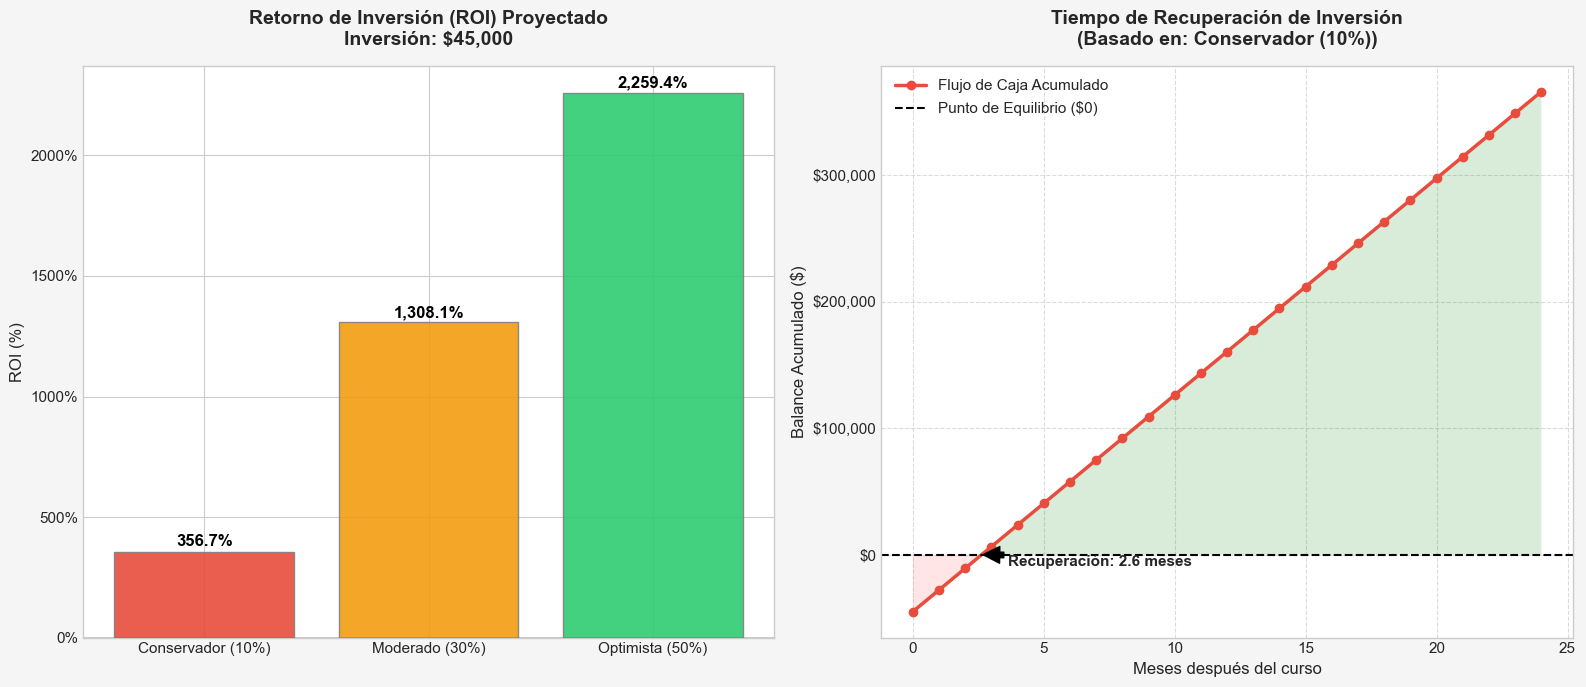

In [6]:
# --- INPUTS (Datos de la Empresa) ---
EMPRESA_EMPLEADOS = 500
SALARIO_PROMEDIO = 15000
COSTO_CURSO = 45000 
MONEDA = "$"

# 1. Ejecutar Modelo
df_roi, costo_base = modelo_roi_bienestar(EMPRESA_EMPLEADOS, SALARIO_PROMEDIO, COSTO_CURSO)

# 2. Mostrar Tabla de Datos
print(f"--- ANÁLISIS FINANCIERO PRELIMINAR ---")
print(f"Costo Oculto Actual (Anual): {MONEDA}{costo_base:,.2f}")
print(f"Inversión Curso: {MONEDA}{COSTO_CURSO:,.2f}")
print("\n--- RESUMEN DE ESCENARIOS ---")
display(df_roi) # Muestra la tabla bonita

# 3. Generar Gráficas
graficar_proyeccion_roi_optimizada(df_roi, COSTO_CURSO, MONEDA)

## 5. Interpretación de Resultados

Basándonos en la visualización de datos generada arriba, podemos concluir la viabilidad del proyecto bajo las siguientes observaciones:

### A. Gráfica Izquierda: Retorno de Inversión (ROI)
Esta gráfica responde a la pregunta: *"¿Cuánto gana la empresa por cada peso invertido?"*

* **Escenario Conservador (Barra Roja):** Incluso si el curso tiene una efectividad baja y solo el **10%** de los fumadores lo deja, el ROI es del **356.7%**.
    * *Traducción:* Por cada \$1.00 que la empresa invierte en el curso, recupera su peso y genera **\$3.56 de ganancia pura** en productividad recuperada durante el primer año.
* **Escenarios Superiores:** Si la efectividad sube al 30% o 50%, las ganancias se vuelven exponenciales (superando el 1000%), lo que indica que el riesgo financiero del proyecto es prácticamente nulo.

### B. Gráfica Derecha: Tiempo de Recuperación (Payback)
Esta gráfica responde a la pregunta: *"¿Cuándo dejamos de perder dinero y empezamos a ganar?"*
* **La Zona Roja (Deuda):** Representa el tiempo en que la inversión inicial ($45,000) aún no ha sido cubierta por los ahorros.
* **El Punto de Equilibrio (Flecha Negra):** La gráfica muestra que la inversión se recupera en **2.6 meses**.
    * *Interpretación:* Si pagamos el curso en Enero, para mediados de Marzo la empresa ya habrá recuperado todo el dinero gracias a la reducción de pausas y absentismo.
* **La Zona Verde (Ganancia):** A partir del mes 3, todo el ahorro generado (la línea ascendente) es utilidad neta directa al estado de resultados de la empresa.

### ✅ Conclusión Ejecutiva
El proyecto es **altamente viable desde una perspectiva financiera**. El riesgo es mínimo dado que, incluso en el peor escenario (Conservador), la inversión se recupera en menos de un trimestre (2.6 meses), ofreciendo un retorno muy superior a cualquier instrumento financiero tradicional.